# Notebook 02: Análisis Exploratorio de Datos (EDA)

## Objetivos

1. Entender la calidad y estructura de los datos
2. Identificar patrones entre contactos que respondieron vs los que no
3. Analizar el funnel de outreach (LinkedIn + email)
4. Explorar las campañas y líneas de producto
5. Justificar la elección de métricas de evaluación

## Datos de entrada

| Archivo | Contenido |
|---------|----------|
| `modeling_dataset_raw.parquet` | 5,987 contactos contactados con features + target |
| `conversation_analytics_ES.parquet` | 11,517 conversaciones (funnel, timing) |
| `daily_analytics_ES.parquet` | 310 días de métricas agregadas |
| `replies_analytics_ES.parquet` | Respuestas mensuales por canal |

## Imports y Configuración

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.templates.default = 'plotly_white'

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from scipy import stats

# Rutas
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
WORKING_DATA = os.path.join(PROJECT_ROOT, '..', '_working', 'data')

# Paleta de colores consistente
COLOR_POS = '#2ecc71'   # Verde para positivos (respondieron)
COLOR_NEG = '#e74c3c'   # Rojo para negativos
COLOR_ACCENT = '#3498db' # Azul acento
COLORS_2 = [COLOR_NEG, COLOR_POS]

In [2]:
# Cargar datos
df = pd.read_parquet(os.path.join(WORKING_DATA, 'modeling_dataset_raw.parquet'))
conv = pd.read_parquet(os.path.join(WORKING_DATA, 'conversation_analytics_ES.parquet'))
daily = pd.read_parquet(os.path.join(WORKING_DATA, 'daily_analytics_ES.parquet'))
replies = pd.read_parquet(os.path.join(WORKING_DATA, 'replies_analytics_ES.parquet'))

print(f'Dataset de modelado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Conversation analytics: {conv.shape[0]:,} filas')
print(f'Daily analytics: {daily.shape[0]} filas')
print(f'Replies analytics: {replies.shape[0]} filas')

Dataset de modelado: 5,987 filas x 48 columnas
Conversation analytics: 11,517 filas
Daily analytics: 310 filas
Replies analytics: 13 filas


---
## 2.1 Calidad de datos y vision general

In [3]:
# Porcentaje de nulos por columna (ordenado)
null_pct = (df.isnull().sum() / len(df) * 100).round(1)
non_null_pct = (100 - null_pct).round(1)

# Columnas con datos vs completamente vacias
empty_cols = null_pct[null_pct == 100].index.tolist()
usable_cols = null_pct[null_pct < 100].index.tolist()

print(f'Columnas con datos: {len(usable_cols)}')
print(f'Columnas completamente vacias: {len(empty_cols)}')
if empty_cols:
    print(f'  -> {empty_cols}')
    print('  (Se eliminaran en NB03)')

Columnas con datos: 48
Columnas completamente vacias: 0


In [4]:
# Visualizacion de completitud por columna
cols_to_show = [c for c in df.columns if c not in empty_cols 
                and c not in ['LinkedIn profile ID', 'Full name', 'First name', 'Last name']]

completeness = pd.DataFrame({
    'columna': cols_to_show,
    'pct_datos': [non_null_pct[c] for c in cols_to_show]
}).sort_values('pct_datos')

fig = px.bar(
    completeness, x='pct_datos', y='columna', orientation='h',
    title='Completitud de datos por columna (%)',
    labels={'pct_datos': '% no nulo', 'columna': ''},
    color='pct_datos',
    color_continuous_scale='RdYlGn',
    range_color=[0, 100],
)
fig.update_layout(height=700, showlegend=False)
fig.show()

In [5]:
# Patron de nulos: se correlacionan con el target?
key_features = ['ai_SENIORITY', 'ai_DEPARTMENT', 'ai_FIT', 'ai_TYPE_OF_CONTACT',
                'Industry', 'Number of employees', 'Years in role', 'Number of connections',
                'Technologies used', 'ai_CONTACT_REPORT', 'ai_COMPANY_REPORT']

null_vs_target = []
for col in key_features:
    if col in df.columns:
        has_data = df[col].notna()
        rate_with = df.loc[has_data, 'target_replied'].mean()
        rate_without = df.loc[~has_data, 'target_replied'].mean() if (~has_data).sum() > 0 else np.nan
        null_vs_target.append({
            'columna': col,
            'pct_no_nulo': has_data.mean() * 100,
            'reply_rate_con_dato': rate_with * 100,
            'reply_rate_sin_dato': rate_without * 100,
        })

null_target_df = pd.DataFrame(null_vs_target).round(1)
print('=== Tasa de respuesta segun disponibilidad de datos ===')
print(null_target_df.to_string(index=False))
print(f'\nTasa global: {df["target_replied"].mean()*100:.1f}%')

=== Tasa de respuesta segun disponibilidad de datos ===
              columna  pct_no_nulo  reply_rate_con_dato  reply_rate_sin_dato
         ai_SENIORITY         99.8                 14.0                 20.0
        ai_DEPARTMENT         99.7                 14.0                 18.8
               ai_FIT         99.9                 14.0                 50.0
   ai_TYPE_OF_CONTACT         89.2                 14.3                 12.1
             Industry         96.1                 13.9                 17.2
  Number of employees         94.6                 14.0                 15.2
        Years in role         92.1                 14.7                  7.0
Number of connections         99.6                 14.0                 32.0
    Technologies used         16.8                 16.2                 13.6
    ai_CONTACT_REPORT         74.5                 15.2                 10.7
    ai_COMPANY_REPORT         98.4                 14.1                 13.4

Tasa global: 14.0%


---
## 2.2 Distribución del target

In [6]:
# Target distribution
target_counts = df['target_replied'].value_counts().sort_index()

fig = make_subplots(rows=1, cols=2, specs=[[{'type': 'bar'}, {'type': 'pie'}]],
                    subplot_titles=['Conteo', 'Proporcion'])

fig.add_trace(
    go.Bar(x=['No respondio', 'Respondio'], y=target_counts.values,
           marker_color=COLORS_2, text=target_counts.values, textposition='auto'),
    row=1, col=1
)

fig.add_trace(
    go.Pie(labels=['No respondio', 'Respondio'], values=target_counts.values,
           marker_colors=COLORS_2, textinfo='percent+label', hole=0.4),
    row=1, col=2
)

fig.update_layout(title='Distribucion de la variable objetivo (target_replied)',
                  height=400, showlegend=False)
fig.show()

print(f'Clase desbalanceada: {df["target_replied"].mean():.1%} positivos')
print(f'Ratio negativo:positivo = {(df["target_replied"]==0).sum()}:{df["target_replied"].sum()} = '
      f'{(df["target_replied"]==0).sum() / max(df["target_replied"].sum(), 1):.0f}:1')

Clase desbalanceada: 14.0% positivos
Ratio negativo:positivo = 5146:841 = 6:1


In [7]:
# Desglose por canal
channel_data = pd.DataFrame({
    'Canal': ['Solo LinkedIn', 'Solo Email', 'Ambos', 'Total respondieron'],
    'Contactos': [
        ((df['target_replied_linkedin'] == 1) & (df['target_replied_email'] == 0)).sum(),
        ((df['target_replied_email'] == 1) & (df['target_replied_linkedin'] == 0)).sum(),
        ((df['target_replied_linkedin'] == 1) & (df['target_replied_email'] == 1)).sum(),
        df['target_replied'].sum(),
    ]
})
print('=== Respuestas por canal ===')
print(channel_data.to_string(index=False))

=== Respuestas por canal ===
             Canal  Contactos
     Solo LinkedIn        536
        Solo Email        305
             Ambos          0
Total respondieron        841


### target_replied vs target_positive

`target_replied` captura **cualquier** respuesta (incluidas negativas como *Not Interested* o *Wrong Person*).  
`target_positive` excluye esas respuestas negativas, modelando solo la probabilidad de una respuesta **útil** para el negocio.

In [8]:
# Comparacion target_replied vs target_positive
fig = make_subplots(rows=1, cols=2, specs=[[{'type': 'bar'}, {'type': 'bar'}]],
                    subplot_titles=['target_replied', 'target_positive'])

for col_idx, col_name in enumerate(['target_replied', 'target_positive'], 1):
    counts = df[col_name].value_counts().sort_index()
    fig.add_trace(
        go.Bar(x=['No', 'Si'], y=counts.values,
               marker_color=['#E8E8E3', '#FFC630'],
               text=counts.values, textposition='outside'),
        row=1, col=col_idx
    )

fig.update_layout(
    title='Comparacion de variables objetivo',
    showlegend=False, height=400,
    template='plotly_white'
)
fig.show()

# Resumen numerico
n = len(df)
replied = df['target_replied'].sum()
positive = df['target_positive'].sum()
reclassified = replied - positive
print(f'target_replied:  {replied:,} respuestas ({replied/n:.1%})')
print(f'target_positive: {positive:,} respuestas utiles ({positive/n:.1%})')
print(f'Reclasificados como negativos: {reclassified:,} ({reclassified/replied:.1%} de las respuestas)')

target_replied:  841 respuestas (14.0%)
target_positive: 717 respuestas utiles (12.0%)
Reclasificados como negativos: 124 (14.7% de las respuestas)


---
## 2.3 Funnel de outreach

Analizamos el embudo completo de prospecting usando los datos diarios agregados.

In [9]:
# Funnel totales
funnel_data = {
    'Audiencia total': daily['total_audience'].max(),
    'Contactados': daily['total_contacted'].max(),
    'LinkedIn enviados': daily['linkedin_messages_sent'].sum(),
    'Conexiones aceptadas': daily['linkedin_connections_accepted'].sum(),
    'LinkedIn replies': daily['linkedin_replies'].sum(),
    'Email enviados': daily['email_sent'].sum(),
    'Email abiertos': daily['email_opened'].sum(),
    'Email clicks': daily['email_clicked'].sum(),
    'Email replies': daily['email_replies'].sum(),
}

print('=== Metricas acumuladas del funnel ===')
for k, v in funnel_data.items():
    print(f'  {k}: {v:,.0f}')

=== Metricas acumuladas del funnel ===
  Audiencia total: 23,674
  Contactados: 465
  LinkedIn enviados: 20,385
  Conexiones aceptadas: 2,784
  LinkedIn replies: 983
  Email enviados: 30,423
  Email abiertos: 0
  Email clicks: 0
  Email replies: 595


In [10]:
# Funnel chart - LinkedIn
linkedin_funnel = pd.DataFrame({
    'Etapa': ['Mensajes enviados', 'Conexiones aceptadas', 'Respuestas'],
    'Valor': [
        daily['linkedin_messages_sent'].sum(),
        daily['linkedin_connections_accepted'].sum(),
        daily['linkedin_replies'].sum(),
    ]
})

fig_ln = go.Figure(go.Funnel(
    y=linkedin_funnel['Etapa'], x=linkedin_funnel['Valor'],
    textinfo='value+percent initial',
    marker_color=['#3498db', '#2ecc71', '#27ae60'],
))
fig_ln.update_layout(title='Funnel LinkedIn', height=350)
fig_ln.show()

# Funnel chart - Email
email_funnel = pd.DataFrame({
    'Etapa': ['Enviados', 'Abiertos', 'Clicks', 'Respuestas'],
    'Valor': [
        daily['email_sent'].sum(),
        daily['email_opened'].sum(),
        daily['email_clicked'].sum(),
        daily['email_replies'].sum(),
    ]
})

fig_em = go.Figure(go.Funnel(
    y=email_funnel['Etapa'], x=email_funnel['Valor'],
    textinfo='value+percent initial',
    marker_color=['#e74c3c', '#f39c12', '#e67e22', '#d35400'],
))
fig_em.update_layout(title='Funnel Email', height=350)
fig_em.show()

In [11]:
# Serie temporal de actividad diaria
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=['Mensajes enviados por dia', 'Respuestas por dia'],
                    vertical_spacing=0.1)

fig.add_trace(
    go.Scatter(x=daily['date'], y=daily['linkedin_messages_sent'],
               name='LinkedIn enviados', line=dict(color='#3498db')),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=daily['date'], y=daily['email_sent'],
               name='Email enviados', line=dict(color='#e74c3c')),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=daily['date'], y=daily['linkedin_replies'],
               name='LinkedIn replies', line=dict(color='#2ecc71')),
    row=2, col=1
)
fig.add_trace(
    go.Scatter(x=daily['date'], y=daily['email_replies'],
               name='Email replies', line=dict(color='#f39c12')),
    row=2, col=1
)

fig.update_layout(height=500, title='Actividad diaria de outreach')
fig.show()

In [12]:
# Tendencia mensual de respuestas (replies_analytics)
fig = go.Figure()
fig.add_trace(go.Bar(x=replies['timestamp'], y=replies['linkedin'],
                     name='LinkedIn', marker_color='#3498db'))
fig.add_trace(go.Bar(x=replies['timestamp'], y=replies['email'],
                     name='Email', marker_color='#e74c3c'))

fig.update_layout(
    title='Respuestas mensuales por canal',
    barmode='group', height=400,
    xaxis_title='Mes', yaxis_title='Respuestas'
)
fig.show()

---
## 2.4 Perfil de converters vs non-converters

Comparamos las caracteristicas de los contactos que respondieron (target=1) vs los que no (target=0).

In [13]:
# Helper: comparar distribucion de una variable categorica entre converters y non-converters
def plot_categorical_comparison(df, col, top_n=10, title=None):
    """Barras agrupadas mostrando tasa de respuesta por categoria."""
    if df[col].notna().sum() == 0:
        print(f'{col}: sin datos')
        return
    
    # Limpiar valores: quedarse solo con la primera linea/frase corta
    cleaned = df[col].copy()
    cleaned = cleaned.astype(str).str.split(r'[\n.]')
    cleaned = cleaned.str[0].str.strip()
    cleaned = cleaned.where(cleaned.str.len() > 0, df[col].astype(str).str[:40])
    cleaned = cleaned.str[:40]  # truncar a 40 chars max
    
    # Calcular tasa de respuesta por categoria
    temp = df[[col, 'target_replied']].copy()
    temp['_label'] = cleaned
    grp = temp.groupby('_label')['target_replied'].agg(['sum', 'count']).reset_index()
    grp.columns = ['_label', 'respondieron', 'total']
    grp['tasa_respuesta'] = (grp['respondieron'] / grp['total'] * 100).round(1)
    grp = grp.sort_values('tasa_respuesta', ascending=False).head(top_n)
    
    fig = make_subplots(rows=1, cols=2, 
                        subplot_titles=['Volumen por categoria', 'Tasa de respuesta (%)'],
                        column_widths=[0.5, 0.5])
    
    fig.add_trace(
        go.Bar(y=grp['_label'], x=grp['total'], orientation='h',
               name='Total', marker_color=COLOR_ACCENT,
               text=grp['total'], textposition='auto'),
        row=1, col=1
    )
    
    fig.add_trace(
        go.Bar(y=grp['_label'], x=grp['tasa_respuesta'], orientation='h',
               name='Tasa respuesta', marker_color=COLOR_POS,
               text=grp['tasa_respuesta'].apply(lambda x: f'{x:.1f}%'), textposition='auto'),
        row=1, col=2
    )
    
    if title is None:
        title = f'Analisis de {col}'
    fig.update_layout(title=title, height=max(350, top_n * 45), showlegend=False)
    fig.show()
    
    # Mostrar tasas de respuesta en texto (para verificacion)
    for _, row in grp.iterrows():
        print(f"  {row['_label']}: {row['tasa_respuesta']:.1f}% ({row['respondieron']}/{row['total']})")
    
    return grp


In [14]:
# Helper: comparar distribucion numerica entre converters y non-converters
def plot_numeric_comparison(df, col, title=None, log_scale=False):
    """Histogramas superpuestos + test estadistico."""
    data = df[df[col].notna()].copy()
    if len(data) == 0:
        print(f'{col}: sin datos')
        return
    
    pos = data[data['target_replied'] == 1][col]
    neg = data[data['target_replied'] == 0][col]
    
    # Test Mann-Whitney (sobre datos originales)
    if len(pos) > 5 and len(neg) > 5:
        stat, pval = stats.mannwhitneyu(pos, neg, alternative='two-sided')
        sig = 'SI' if pval < 0.05 else 'NO'
    else:
        pval, sig = np.nan, 'N/A'
    
    # Clipar al percentil 1-99 para histograma legible
    all_vals = data[col]
    lo, hi = all_vals.quantile(0.01), all_vals.quantile(0.99)
    pos_clip = pos.clip(lo, hi)
    neg_clip = neg.clip(lo, hi)
    
    fig = go.Figure()
    fig.add_trace(go.Histogram(x=neg_clip, name='No respondio', opacity=0.7,
                               marker_color=COLOR_NEG, nbinsx=40))
    fig.add_trace(go.Histogram(x=pos_clip, name='Respondio', opacity=0.7,
                               marker_color=COLOR_POS, nbinsx=40))
    
    if title is None:
        title = col
    fig.update_layout(
        title=f'{title} (p={pval:.4f}, significativo: {sig})',
        barmode='overlay', height=350,
        xaxis_title=col, yaxis_title='Frecuencia',
    )
    if log_scale:
        fig.update_xaxes(type='log')
    fig.show()
    
    print(f'  Mediana respondieron: {pos.median():.1f} | No respondieron: {neg.median():.1f}')


### 2.4.1 ai_SENIORITY (nivel jerárquico)

El nivel jerárquico determina la capacidad de decisión del contacto. Un Director o C-level puede aprobar una compra directamente, mientras que un Junior necesita escalar. Analizamos si la jerarquia influye en la probabilidad de respuesta.

In [15]:
plot_categorical_comparison(df, 'ai_SENIORITY',
                           title='Nivel jerarquico (ai_SENIORITY) vs tasa de respuesta')

  TRAINEE: 41.7% (5/12)
  OTHER: 25.2% (29/115)
  None: 20.0% (2/10)
  VP: 19.6% (9/46)
  MANAGER: 16.2% (157/969)
  LEAD: 14.4% (143/994)
  JR: 13.8% (156/1131)
  DIRECTOR: 13.0% (235/1801)
  OWNER: 12.5% (14/112)
  CLEVEL: 11.4% (91/797)


,_label,respondieron,total,tasa_respuesta
8,TRAINEE,5,12,41.7
6,OTHER,29,115,25.2
5,None,2,10,20.0
9,VP,9,46,19.6
4,MANAGER,157,969,16.2
3,LEAD,143,994,14.4
2,JR,156,1131,13.8
1,DIRECTOR,235,1801,13.0
7,OWNER,14,112,12.5
0,CLEVEL,91,797,11.4


### 2.4.2 ai_DEPARTMENT

El departamento indica el area funciónal del contacto dentro de la empresa. Dependiendo del producto que se ofrece, ciertos departamentos (IT, Digital, Operations) pueden ser más receptivos que otros.

In [16]:
plot_categorical_comparison(df, 'ai_DEPARTMENT',
                           title='Departamento (ai_DEPARTMENT) vs tasa de respuesta')

  None: 18.8% (3/16)
  Sales & MKT: 18.1% (137/756)
  Other: 14.8% (153/1037)
  OPerations: 14.4% (166/1150)
  IT: 13.0% (329/2531)
  Finance: 10.7% (53/497)


,_label,respondieron,total,tasa_respuesta
2,None,3,16,18.8
5,Sales & MKT,137,756,18.1
4,Other,153,1037,14.8
3,OPerations,166,1150,14.4
1,IT,329,2531,13.0
0,Finance,53,497,10.7


### 2.4.3 ai_TYPE_OF_CONTACT (tipo de contacto)

TYPE OF CONTACT clasifica el rol del contacto en el proceso de compra: Key Decisión Maker, Buyer/Champion, Influencer o Referral. Esta variable sustituye al Contact Score generico (High/Medium/Low) porque describe el rol funciónal, más relevante para predecir la respuesta.

In [17]:
plot_categorical_comparison(df, 'ai_TYPE_OF_CONTACT',
                           title='Tipo de contacto (ai_TYPE_OF_CONTACT) vs tasa de respuesta')

  🛑 NULL: 21.0% (33/157)
  🚀 Champion-Buyer: 19.8% (75/379)
  🤝 Referidor: 19.5% (165/847)
  🚀 Champion: 16.0% (50/312)
  🎩 Decisor 📞: 12.9% (9/70)
  🎩 INFLUENCER: 12.8% (128/1000)
  None: 12.1% (78/646)
  🤝 Referer: 12.1% (247/2044)
  🎩📞 Decisor: 11.3% (55/488)
  🎩 Decisor: 2.5% (1/40)


,_label,respondieron,total,tasa_respuesta
8,🛑 NULL,33,157,21.0
7,🚀 Champion-Buyer,75,379,19.8
10,🤝 Referidor,165,847,19.5
6,🚀 Champion,50,312,16.0
3,🎩 Decisor 📞,9,70,12.9
4,🎩 INFLUENCER,128,1000,12.8
0,None,78,646,12.1
9,🤝 Referer,247,2044,12.1
5,🎩📞 Decisor,55,488,11.3
1,🎩 Decisor,1,40,2.5


### 2.4.4 ai_FIT (puntuación general de fit)

El FIT score es una puntuación generada por la IA de Raona que indica como de bien encaja el contacto/empresa con el perfil de cliente ideal. Valores posibles: Very High, High, Medium, Low. Analizamos si un FIT alto se traduce en mayor probabilidad de respuesta.

In [18]:
# ai_FIT simplificado
def simplify_fit(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).upper()
    if 'HOT' in val_str:
        return 'HOT LEAD'
    if 'DESAPROBADO' in val_str or 'DESARPOBADO' in val_str:
        return 'DESAPROBADO'
    if 'APROBADO' in val_str:
        return 'APROBADO'
    if 'DUDA' in val_str:
        return 'DUDA'
    if 'MIGRACION' in val_str:
        return 'MIGRACION'
    if 'COMPETITOR' in val_str:
        return 'COMPETITOR'
    return 'OTRO'

df['ai_FIT_clean'] = df['ai_FIT'].apply(simplify_fit)
plot_categorical_comparison(df, 'ai_FIT_clean',
                           title='FIT general simplificado vs tasa de respuesta')

  nan: 50.0% (4/8)
  COMPETITOR: 20.0% (1/5)
  HOT LEAD: 19.0% (8/42)
  DESAPROBADO: 17.4% (55/316)
  MIGRACION: 16.2% (13/80)
  DUDA: 16.0% (25/156)
  OTRO: 15.4% (18/117)
  APROBADO: 13.6% (717/5263)


,_label,respondieron,total,tasa_respuesta
7,nan,4,8,50.0
1,COMPETITOR,1,5,20.0
4,HOT LEAD,8,42,19.0
2,DESAPROBADO,55,316,17.4
5,MIGRACION,13,80,16.2
3,DUDA,25,156,16.0
6,OTRO,18,117,15.4
0,APROBADO,717,5263,13.6


### 2.4.5 ai_FIT por producto (disponibilidad y efecto)

Raona ofrece 6 líneas de producto y calcula un FIT específico por cada una. Aquí analizamos cuantos contactos tienen cada FIT de producto y si alguno muestra una relacion clara con la tasa de respuesta.

In [19]:
# FIT scores por producto individual
fit_product_cols = [c for c in ['ai_FIT_IA', 'ai_FIT_COLABORA', 'ai_FIT_INFRA',
                    'ai_FIT_DATA', 'ai_FIT_WORKPLACE', 'ai_FIT_MAITE'] if c in df.columns]

# Solo analizar las que existen en el dataset
fit_product_cols = [c for c in fit_product_cols if c in df.columns]

for col in fit_product_cols:
    non_null = df[col].notna().sum()
    pct = non_null / len(df) * 100
    if pct > 5:
        print(f'\n{col}: {non_null} datos ({pct:.1f}%)')
        plot_categorical_comparison(df, col, title=f'{col} vs tasa de respuesta')
    else:
        print(f'{col}: solo {non_null} datos ({pct:.1f}%) - insuficiente para analisis')

ai_FIT_IA: solo 39 datos (0.7%) - insuficiente para analisis
ai_FIT_COLABORA: solo 18 datos (0.3%) - insuficiente para analisis

ai_FIT_DATA: 5979 datos (99.9%)


  None: 37.5% (3/8)
  DUDA: 22.2% (2/9)
  NO: 20.2% (21/104)
  SI: 14.0% (797/5704)
  COMPETITOR: 11.1% (18/162)


### 2.4.6 ai_FIT_DATA (único FIT por producto con datos suficientes)

De todos los FIT por producto, solo FIT_DATA tiene suficientes datos no nulos para ser útil como feature. Los demás tienen demasiados valores faltantes. Analizamos FIT_DATA en detalle como representante de los FIT específicos.

In [20]:
# ai_FIT_DATA tiene 99.9% de datos con valores: SI, NO, COMPETITOR, DUDA
plot_categorical_comparison(df, 'ai_FIT_DATA',
                           title='FIT DATA (Power BI, Fabric) vs tasa de respuesta')

  None: 37.5% (3/8)
  DUDA: 22.2% (2/9)
  NO: 20.2% (21/104)
  SI: 14.0% (797/5704)
  COMPETITOR: 11.1% (18/162)


,_label,respondieron,total,tasa_respuesta
3,None,3,8,37.5
1,DUDA,2,9,22.2
2,NO,21,104,20.2
4,SI,797,5704,14.0
0,COMPETITOR,18,162,11.1


### 2.4.7 ai_Microsoft (usa tecnologia Microsoft)

Indica si la empresa del contacto ya usa tecnologia Microsoft. Dado que Raona es Microsoft Gold Partner, las empresas que ya usan Microsoft podrian ser más receptivas a servicios complementarios.

In [21]:
plot_categorical_comparison(df, 'ai_Microsoft',
                           title='Usa Microsoft? vs tasa de respuesta')

  0: 14.8% (168/1132)
  1: 14.2% (605/4269)
  nan: 11.6% (68/586)


,_label,respondieron,total,tasa_respuesta
0,0,168,1132,14.8
1,1,605,4269,14.2
2,nan,68,586,11.6


### 2.4.8 Industry (sector de la empresa)

El sector de la empresa puede indicar madurez digital y receptividad a servicios tecnologicos. Sectores como IT o Financial Services pueden tener necesidades más inmediatas que otros.

In [22]:
plot_categorical_comparison(df, 'Industry', top_n=20,
                           title='Top 20 industrias por volumen y tasa de respuesta')

  Fundraising: 100.0% (1/1)
  Utility System Construction: 100.0% (1/1)
  Commercial and Industrial Equipment Rent: 100.0% (1/1)
  Oil, Gas, and Mining: 100.0% (1/1)
  Recreational Facilities: 100.0% (1/1)
  Space Research and Technology: 50.0% (1/2)
  Nursing Homes and Residential Care Facil: 50.0% (1/2)
  Wind Electric Power Generation: 50.0% (1/2)
  Printing Services: 50.0% (2/4)
  Staffing and Recruiting: 40.0% (2/5)
  Public Relations and Communications Serv: 38.5% (5/13)
  Wholesale: 35.3% (6/17)
  Security and Investigations: 33.9% (19/56)
  Paper and Forest Product Manufacturing: 33.3% (4/12)
  Paper & Forest Products: 33.3% (1/3)
  Professional Services: 33.3% (2/6)
  Entertainment Providers: 33.3% (5/15)
  Public Policy Offices: 33.3% (1/3)
  Health, Wellness & Fitness: 33.3% (1/3)
  Non-profit Organization Management: 33.3% (1/3)


,_label,respondieron,total,tasa_respuesta
53,Fundraising,1,1,100.0
173,Utility System Construction,1,1,100.0
21,Commercial and Industrial Equipment Rent,1,1,100.0
109,"Oil, Gas, and Mining",1,1,100.0
130,Recreational Facilities,1,1,100.0
155,Space Research and Technology,1,2,50.0
107,Nursing Homes and Residential Care Facil,1,2,50.0
179,Wind Electric Power Generation,1,2,50.0
120,Printing Services,2,4,50.0
159,Staffing and Recruiting,2,5,40.0


### 2.4.9 Variables numéricas

Variables como el número de empleados, conexiones LinkedIn o antiguedad en el puesto describen el tamaño de la empresa y la visibilidad del contacto. Analizamos sus distribuciones y correlación con la respuesta.

In [23]:
plot_numeric_comparison(df, 'Number of employees', 
                       title='Numero de empleados', log_scale=True)

  Mediana respondieron: 745.0 | No respondieron: 588.0


In [24]:
plot_numeric_comparison(df, 'Years in role', title='Anos en el puesto')

  Mediana respondieron: 2.4 | No respondieron: 3.3


In [25]:
plot_numeric_comparison(df, 'Number of connections', 
                       title='Numero de conexiones LinkedIn', log_scale=True)

  Mediana respondieron: 893.5 | No respondieron: 645.5


In [26]:
plot_numeric_comparison(df, 'Year founded', title='Ano de fundacion de la empresa')

  Mediana respondieron: 1982.0 | No respondieron: 1979.0


In [27]:
# Headcount growth comparisons
for col in ['Yearly headcount growth', 'Two years headcount growth']:
    if df[col].notna().sum() > 100:
        plot_numeric_comparison(df, col, title=col)

  Mediana respondieron: 5.0 | No respondieron: 5.0


  Mediana respondieron: 14.0 | No respondieron: 13.0


### 2.4.10 Resumen estadístico: converters vs non-converters

In [28]:
# Tabla resumen de diferencias significativas
numeric_features = ['Years in role', 'Years in company', 'Number of connections',
                    'Number of employees', 'Year founded',
                    'Yearly headcount growth', 'Two years headcount growth']

summary_rows = []
for col in numeric_features:
    data = df[df[col].notna()]
    pos = data[data['target_replied'] == 1][col]
    neg = data[data['target_replied'] == 0][col]
    if len(pos) > 5 and len(neg) > 5:
        stat, pval = stats.mannwhitneyu(pos, neg, alternative='two-sided')
        summary_rows.append({
            'Feature': col,
            'Mediana (respondio)': pos.median(),
            'Mediana (no respondio)': neg.median(),
            'p-value': pval,
            'Significativo': 'SI' if pval < 0.05 else 'NO',
        })

summary_df = pd.DataFrame(summary_rows)
print('=== Test Mann-Whitney: converters vs non-converters ===')
print(summary_df.to_string(index=False))

=== Test Mann-Whitney: converters vs non-converters ===
                   Feature  Mediana (respondio)  Mediana (no respondio)      p-value Significativo
             Years in role                2.375                    3.33 1.153029e-13            SI
          Years in company                4.330                    5.75 4.471704e-08            SI
     Number of connections              890.000                  611.00 3.750460e-17            SI
       Number of employees              745.000                  588.00 6.657236e-06            SI
              Year founded             1982.000                 1979.00 2.680524e-01            NO
   Yearly headcount growth                5.000                    5.00 6.447861e-01            NO
Two years headcount growth               14.000                   13.00 7.623233e-01            NO


In [29]:
# Chi-square tests para categoricas
cat_features = ['ai_SENIORITY', 'ai_DEPARTMENT', 'ai_TYPE_OF_CONTACT',
                'ai_FIT_clean', 'ai_FIT_DATA', 'ai_Microsoft']

chi2_rows = []
for col in cat_features:
    data = df[df[col].notna()]
    if data[col].nunique() < 2:
        continue
    ct = pd.crosstab(data[col], data['target_replied'])
    if ct.shape[0] >= 2 and ct.shape[1] >= 2:
        chi2, pval, dof, expected = stats.chi2_contingency(ct)
        chi2_rows.append({
            'Feature': col,
            'Chi2': chi2,
            'p-value': pval,
            'Significativo': 'SI' if pval < 0.05 else 'NO',
        })

chi2_df = pd.DataFrame(chi2_rows)
print('=== Test Chi-cuadrado: asociacion con target ===')
print(chi2_df.to_string(index=False))

print('\nNota: Se realizaron multiples tests sin correccion de Bonferroni.')
print('Para inferencia formal, aplicar correccion por comparaciones multiples.')


=== Test Chi-cuadrado: asociacion con target ===
           Feature      Chi2      p-value Significativo
      ai_SENIORITY 30.800360 1.524731e-04            SI
     ai_DEPARTMENT 17.995535 1.236580e-03            SI
ai_TYPE_OF_CONTACT 71.882747 8.947976e-08            SI
      ai_FIT_clean  5.755953 4.510762e-01            NO
       ai_FIT_DATA  4.938115 1.763851e-01            NO
      ai_Microsoft  0.274306 6.004575e-01            NO

Nota: Se realizaron multiples tests sin correccion de Bonferroni.
Para inferencia formal, aplicar correccion por comparaciones multiples.


---
## 2.5 Análisis de campañas

Extraemos la línea de producto y el canal de cada campaña a partir del nombre.

In [30]:
# Parsear campaignName para extraer producto y canal
def extract_product(name):
    """Extrae la linea de producto del nombre de campaña.
    
    Productos: COLABORA, COMUNICA, IA, INFRA, DATA, WORKPLACE, MAITE
    CONNECTION es un paso operativo, no un producto -> se excluye del analisis de productos.
    """
    name_upper = str(name).upper()
    if 'MAITE' in name_upper or 'GOB' in name_upper or 'ADOP' in name_upper:
        return 'MAITE'
    if ' IA' in name_upper or 'IA ' in name_upper or name_upper.endswith(' IA'):
        return 'IA'
    if 'WORKPLACE' in name_upper:
        return 'WORKPLACE'
    if 'DATA' in name_upper:
        return 'DATA'
    if 'INFRA' in name_upper:
        return 'INFRA'
    # COMUNICA y COLABORA ahora separados (antes se agrupaban como COLABORA)
    if 'COMUNICA' in name_upper:
        return 'COMUNICA'
    if 'COLABORA' in name_upper or 'GESTION DOCUMENTAL' in name_upper:
        return 'COLABORA'
    # CI = Colabora + Infra (campañas mixtas) -> asignar a COLABORA
    if ' CI ' in name_upper or name_upper.endswith(' CI') or '(CI)' in name_upper:
        return 'COLABORA'
    # CONNECTION es operativo, no producto
    if 'CONNECTION' in name_upper or 'CONNECT' in name_upper:
        return 'CONNECTION'
    # RBY (Raona Business Yield) sin producto claro
    if 'RBY' in name_upper:
        return 'OTHER'
    return 'OTHER'

def extract_channel(name):
    """Extrae el canal del nombre de campaña."""
    name_upper = str(name).upper()
    if 'LINKEDIN' in name_upper or 'LKN' in name_upper or 'LKD' in name_upper:
        return 'LinkedIn'
    if 'MAIL' in name_upper or 'EMAIL' in name_upper:
        return 'Email'
    if 'CONNECTION' in name_upper:
        return 'LinkedIn'
    return 'Otro'

conv['product'] = conv['campaignName'].apply(extract_product)
conv['channel'] = conv['campaignName'].apply(extract_channel)

# Crear target en conversation analytics
conv['target_replied'] = ((conv['linkedinReplied'] > 0) | (conv['emailReplied'] > 0)).astype(int)

print('=== Campañas por producto ===')
print(conv['product'].value_counts())
print(f'\n=== Campañas por canal ===')
print(conv['channel'].value_counts())
print(f'\nNota: CONNECTION es un paso operativo (envio de conexion), no una linea de producto.')

=== Campañas por producto ===
product
OTHER         3017
MAITE         2180
WORKPLACE     1561
COLABORA      1419
DATA          1353
INFRA          991
IA             753
COMUNICA       231
CONNECTION      12
Name: count, dtype: int64

=== Campañas por canal ===
channel
Email       9287
LinkedIn    2022
Otro         208
Name: count, dtype: int64

Nota: CONNECTION es un paso operativo (envio de conexion), no una linea de producto.


In [31]:
# Tasa de respuesta por producto
# Excluir CONNECTION del analisis de productos (es paso operativo)
conv_products = conv[conv['product'] != 'CONNECTION']
product_stats = conv_products.groupby('product')['target_replied'].agg(['sum', 'count', 'mean']).reset_index()
product_stats.columns = ['Producto', 'Respuestas', 'Conversaciones', 'Tasa']
product_stats['Tasa_pct'] = (product_stats['Tasa'] * 100).round(1)
product_stats = product_stats.sort_values('Conversaciones', ascending=False)

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Volumen de conversaciones', 'Tasa de respuesta (%)'])

fig.add_trace(
    go.Bar(y=product_stats['Producto'], x=product_stats['Conversaciones'],
           orientation='h', marker_color=COLOR_ACCENT,
           text=product_stats['Conversaciones'], textposition='auto'),
    row=1, col=1
)

fig.add_trace(
    go.Bar(y=product_stats['Producto'], x=product_stats['Tasa_pct'],
           orientation='h', marker_color=COLOR_POS,
           text=product_stats['Tasa_pct'].apply(lambda x: f'{x}%'), textposition='auto'),
    row=1, col=2
)

fig.update_layout(title='Conversion por linea de producto (nivel conversacion)',
                  height=400, showlegend=False)
fig.show()

print(product_stats[['Producto', 'Conversaciones', 'Respuestas', 'Tasa_pct']].to_string(index=False))

 Producto  Conversaciones  Respuestas  Tasa_pct
    OTHER            3017         760      25.2
    MAITE            2180         211       9.7
WORKPLACE            1561          99       6.3
 COLABORA            1419         133       9.4
     DATA            1353          78       5.8
    INFRA             991          64       6.5
       IA             753          42       5.6
 COMUNICA             231          51      22.1


In [32]:
# Tasa de respuesta por campaña individual (scatter: volumen vs conversion)
campaign_stats = conv.groupby('campaignName').agg(
    conversaciones=('target_replied', 'count'),
    respuestas=('target_replied', 'sum'),
    tasa=('target_replied', 'mean'),
    producto=('product', 'first'),
    canal=('channel', 'first'),
).reset_index()
campaign_stats['tasa_pct'] = (campaign_stats['tasa'] * 100).round(1)

fig = px.scatter(
    campaign_stats, x='conversaciones', y='tasa_pct',
    color='producto', size='respuestas',
    hover_name='campaignName',
    title='Campanas: volumen vs tasa de conversion',
    labels={'conversaciones': 'Conversaciones', 'tasa_pct': 'Tasa respuesta (%)',
            'producto': 'Producto'},
    height=500,
)
fig.show()

In [33]:
# Canal: LinkedIn vs Email
channel_stats = conv.groupby('channel')['target_replied'].agg(['sum', 'count', 'mean']).reset_index()
channel_stats.columns = ['Canal', 'Respuestas', 'Conversaciones', 'Tasa']
channel_stats['Tasa_pct'] = (channel_stats['Tasa'] * 100).round(1)

print('=== Conversion por canal ===')
print(channel_stats.to_string(index=False))

=== Conversion por canal ===
   Canal  Respuestas  Conversaciones     Tasa  Tasa_pct
   Email         599            9287 0.064499       6.4
LinkedIn         778            2022 0.384768      38.5
    Otro          67             208 0.322115      32.2


---
## 2.6 Análisis de timing

Día de la semana y mes en que se obtienen mejores tasas de respuesta.

In [34]:
# Dia de la semana
daily['dow_num'] = daily['date'].dt.dayofweek

DAYS_ES = {0: 'Lunes', 1: 'Martes', 2: 'Miercoles', 3: 'Jueves',
           4: 'Viernes', 5: 'Sabado', 6: 'Domingo'}
DAYS_ORDER = ['Lunes','Martes','Miercoles','Jueves','Viernes','Sabado','Domingo']
daily['day_of_week'] = daily['dow_num'].map(DAYS_ES)

# --- Grafico 1: Respuestas totales por dia (lunes a domingo) ---
dow_replies = daily.groupby(['dow_num', 'day_of_week']).agg(
    total_replies=('total_replies', 'sum'),
    linkedin_replies=('linkedin_replies', 'sum'),
    email_replies=('email_replies', 'sum'),
).reset_index().sort_values('dow_num')

fig = go.Figure()
fig.add_trace(go.Bar(
    x=dow_replies['day_of_week'], y=dow_replies['total_replies'],
    marker_color=COLOR_ACCENT,
    text=dow_replies['total_replies'], textposition='auto',
    name='Total'
))
fig.update_layout(
    title='Respuestas recibidas por dia de la semana (lunes a domingo)',
    yaxis_title='Respuestas totales', height=400,
    xaxis=dict(categoryorder='array', categoryarray=DAYS_ORDER)
)
fig.show()

print(f'Fin de semana: {dow_replies[dow_replies.dow_num >= 5].total_replies.sum()} '
      f'respuestas ({dow_replies[dow_replies.dow_num >= 5].total_replies.sum() / dow_replies.total_replies.sum() * 100:.1f}% del total)')

# --- Grafico 2: Tasa de respuesta en dias laborables (L-V) ---
min_sends = 20
active_days = daily[(daily['linkedin_messages_sent'] + daily['email_sent']) >= min_sends].copy()
print(f'\nDias laborables con >= {min_sends} envios: {len(active_days)} de {len(daily)}')
active_days['reply_rate'] = (
    (active_days['linkedin_replies'] + active_days['email_replies']) /
    (active_days['linkedin_messages_sent'] + active_days['email_sent']).clip(lower=1)
) * 100

dow_rate = active_days.groupby(['dow_num', 'day_of_week']).agg(
    dias=('reply_rate', 'count'),
    tasa_media=('reply_rate', 'mean'),
).reset_index().sort_values('dow_num')

fig = go.Figure()
fig.add_trace(go.Bar(
    x=dow_rate['day_of_week'], y=dow_rate['tasa_media'].round(1),
    marker_color=COLOR_POS,
    text=dow_rate['tasa_media'].round(1).apply(lambda x: f'{x}%'),
    textposition='auto'
))
fig.update_layout(
    title='Tasa de respuesta media por dia de envio (solo dias laborables con >= 20 envios)',
    yaxis_title='Tasa respuesta (%)', height=400,
    xaxis=dict(categoryorder='array', categoryarray=DAYS_ORDER)
)
fig.show()


Fin de semana: 67 respuestas (3.0% del total)

Dias laborables con >= 20 envios: 182 de 310


In [35]:
# Tendencia mensual
daily['month'] = daily['date'].dt.to_period('M').astype(str)
monthly = daily.groupby('month').agg(
    enviados=('linkedin_messages_sent', 'sum'),
    email_enviados=('email_sent', 'sum'),
    replies_ln=('linkedin_replies', 'sum'),
    replies_em=('email_replies', 'sum'),
).reset_index()
monthly['total_enviados'] = monthly['enviados'] + monthly['email_enviados']
monthly['total_replies'] = monthly['replies_ln'] + monthly['replies_em']
monthly['tasa'] = (monthly['total_replies'] / monthly['total_enviados'].clip(lower=1) * 100).round(1)

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=['Volumen mensual', 'Tasa de respuesta mensual (%)'])

fig.add_trace(
    go.Bar(x=monthly['month'], y=monthly['total_enviados'], name='Enviados',
           marker_color=COLOR_ACCENT),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=monthly['month'], y=monthly['total_replies'], name='Respuestas',
           marker_color=COLOR_POS),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=monthly['month'], y=monthly['tasa'], name='Tasa %',
               line=dict(color=COLOR_POS, width=3), mode='lines+markers'),
    row=2, col=1
)

fig.update_layout(title='Evolucion mensual del outreach', height=500)
fig.show()

---
## 2.7 Exploración de campos de texto (preview para NLP)

Los campos `ai_CONTACT_REPORT`, `ai_COMPANY_REPORT` y `ai_MOMENTUM` contienen texto generado por IA 
que procesaremos con NLP en NB03. Aquí hacemos una exploración basica.

In [36]:
# Disponibilidad de campos de texto
text_cols = ['ai_CONTACT_REPORT', 'ai_COMPANY_REPORT', 'ai_MOMENTUM']
for col in text_cols:
    non_null = df[col].notna().sum()
    pct = non_null / len(df) * 100
    if non_null > 0:
        lengths = df[col].dropna().str.len()
        print(f'{col}: {non_null:,} ({pct:.1f}%) | '
              f'longitud media: {lengths.mean():.0f} chars, '
              f'mediana: {lengths.median():.0f}, max: {lengths.max():,.0f}')
    else:
        print(f'{col}: {non_null} ({pct:.1f}%)')

ai_CONTACT_REPORT: 4,458 (74.5%) | longitud media: 2937 chars, mediana: 2906, max: 7,648
ai_COMPANY_REPORT: 5,890 (98.4%) | longitud media: 8064 chars, mediana: 8094, max: 15,475
ai_MOMENTUM: 1,334 (22.3%) | longitud media: 2315 chars, mediana: 2325, max: 4,219


In [37]:
# Longitud de texto vs target
for col in text_cols:
    if df[col].notna().sum() > 100:
        df[f'_len_{col}'] = df[col].str.len()
        plot_numeric_comparison(df, f'_len_{col}', 
                               title=f'Longitud de {col} (caracteres)')
        df.drop(columns=[f'_len_{col}'], inplace=True)

  Mediana respondieron: 2883.0 | No respondieron: 2910.5


  Mediana respondieron: 8013.5 | No respondieron: 8104.0


  Mediana respondieron: 2197.0 | No respondieron: 2344.0


In [38]:
# Muestras de texto: converters vs non-converters
for col in ['ai_COMPANY_REPORT', 'ai_MOMENTUM']:
    if df[col].notna().sum() > 10:
        print(f'\n{"="*60}')
        print(f'MUESTRAS DE {col}')
        print(f'{"="*60}')
        
        converters = df[(df['target_replied'] == 1) & (df[col].notna())]
        non_converters = df[(df['target_replied'] == 0) & (df[col].notna())]
        
        if len(converters) > 0:
            print(f'\n--- RESPONDIERON (muestra de {min(3, len(converters))}) ---')
            for _, row in converters.sample(min(3, len(converters)), random_state=42).iterrows():
                print(f'  [{row["Company name"]}] {str(row[col])[:300]}...')
                print()
        
        if len(non_converters) > 0:
            print(f'--- NO RESPONDIERON (muestra de {min(3, len(non_converters))}) ---')
            for _, row in non_converters.sample(min(3, len(non_converters)), random_state=42).iterrows():
                print(f'  [{row["Company name"]}] {str(row[col])[:300]}...')
                print()


MUESTRAS DE ai_COMPANY_REPORT

--- RESPONDIERON (muestra de 3) ---
  [Cuerva] Informe ejecutivo (nivel Senior Big‑Three) — Cuerva (empresa energética, Granada)

1) Resumen ejecutivo
- Qué hacen: Grupo energético integrado (generación renovable, distribución, comercialización y Smart Services / Smart Solutions: autoconsumo, movilidad eléctrica, telecomunicaciones, sistemas de ...

  [SESCAM] Compelling reasons y desencadenantes para outreach a SESCAM (Servicio de Salud de Castilla-La Mancha) sobre una solución de Comunicación Interna nativa de Microsoft 365 (Raona – Communication Hub):

1) Transformación digital y gestión de comunicaciones en salud pública
- SESCAM está inmerso en moder...

  [Majestic Hotel Group] Reporte de información relevante para Majestic Hotel Group (sector Hospitality) orientado a venta de una solución de comunicación interna integrada en Microsoft 365 (Raona – Communication Hub).

1) Resumen ejecutivo de Majestic Hotel Group
- Perfil: Grupo hotelero catalán co

### 2.7.1 Impacto del proceso de cualificación IA

Un 25.5% de los contactos no tienen `ai_CONTACT_REPORT` (`nlp_contact_report_length = 0`). Esto se debe a diferencias operativas entre campañas:

- **Connection Accepted**: el 96.3% no tiene report (nunca se les envió un mensaje).
- **Campañas antiguas (v1.3)**: entre el 85-89% sin report.
- **Campañas recientes (v1.5 / v1.6)**: solo el 0-3% sin report.
- **Tasa de respuesta**: ~7% sin report vs ~38% con report (en campañas recientes).

**Conclusión**: la introducción del proceso de cualificación IA transformó los resultados del outreach. Las campañas recientes, que incorporan la cualificación IA de forma sistemática, muestran tasas de respuesta significativamente superiores.

In [ ]:
# --- 2.7.1 Impacto del proceso de cualificacion IA ---

# Indicador: tiene ai_CONTACT_REPORT
has_report = df['ai_CONTACT_REPORT'].notna() & (df['ai_CONTACT_REPORT'] != '')
print(f"Contactos CON ai_CONTACT_REPORT: {has_report.sum()} ({has_report.mean()*100:.1f}%)")
print(f"Contactos SIN ai_CONTACT_REPORT: {(~has_report).sum()} ({(~has_report).mean()*100:.1f}%)")

# Tabulacion cruzada con campaign_engagement_status
print("\n--- % SIN report por campaign_engagement_status ---")
ct_status = pd.crosstab(df['campaign_engagement_status'], has_report, normalize='index')
ct_status.columns = ['Sin report', 'Con report']
print((ct_status * 100).round(1))

# Tabulacion cruzada con version de campana
if 'campaign_version' in df.columns:
    version_col = 'campaign_version'
elif 'campaignName' in df.columns:
    # Extraer version del nombre de campana
    df['_campaign_version'] = df['campaignName'].str.extract(r'(v\d+\.\d+)', expand=False).fillna('sin_version')
    version_col = '_campaign_version'
else:
    version_col = None

if version_col:
    print(f"\n--- % SIN report por version de campana ---")
    ct_version = pd.crosstab(df[version_col], has_report, normalize='index')
    ct_version.columns = ['Sin report', 'Con report']
    print((ct_version * 100).round(1))

# Comparacion de tasa de respuesta: con report vs sin report
target_col = 'target_replied' if 'target_replied' in df.columns else 'target_positive'
print(f"\n--- Tasa de respuesta ({target_col}) por presencia de report ---")
rate_by_report = df.groupby(has_report)[target_col].mean() * 100
rate_by_report.index = ['Sin report', 'Con report']
print(rate_by_report.round(1))

# Desglose por version + report
if version_col:
    print(f"\n--- Tasa de respuesta por version y presencia de report ---")
    rate_detail = df.groupby([df[version_col], has_report])[target_col].agg(['mean', 'count'])
    rate_detail.columns = ['tasa_respuesta', 'n_contactos']
    rate_detail['tasa_respuesta'] = (rate_detail['tasa_respuesta'] * 100).round(1)
    rate_detail.index.names = ['version', 'has_report']
    print(rate_detail)

    # Limpiar columna temporal
    if '_campaign_version' in df.columns:
        df.drop(columns=['_campaign_version'], inplace=True)

---
## 2.8 Análisis de Conversation tags

Las conversation tags indican el resultado cualitativo de las conversaciones.
Analizamos que proporción de respuestas son realmente positivas (MEETING, Follow Up)
vs negativas o neutrales.

In [39]:
# Analisis de Conversation tags para contactos que respondieron
replied = df[df['target_replied'] == 1].copy()
print(f'Contactos que respondieron: {len(replied)}')
print(f'Con conversation tags: {replied["Conversation tags"].notna().sum()}')

# Desglose de tags
tags = replied['Conversation tags'].dropna()
print(f'\n=== Conversation tags en respuestas ({len(tags)} con tags) ===')
tag_counts = tags.value_counts()
for tag, count in tag_counts.items():
    pct = count / len(tags) * 100
    print(f'  {tag}: {count} ({pct:.1f}%)')

# Clasificar tags como positivas, negativas, o neutras
def classify_tag(tag):
    if pd.isna(tag):
        return 'Sin tag'
    tag_upper = str(tag).upper()
    if 'MEETING' in tag_upper or 'POSITIVE' in tag_upper:
        return 'Positiva (Meeting/Positive)'
    if 'FOLLOW' in tag_upper or 'REFERRED' in tag_upper:
        return 'Seguimiento (Follow Up/Referred)'
    if 'NEGATIVE' in tag_upper or 'NOT INTERESTED' in tag_upper:
        return 'Negativa'
    return 'Otra'

replied['tag_class'] = replied['Conversation tags'].apply(classify_tag)
tag_class_counts = replied['tag_class'].value_counts()

fig = go.Figure(go.Pie(
    labels=tag_class_counts.index,
    values=tag_class_counts.values,
    marker_colors=['#2ecc71', '#f1c40f', '#e74c3c', '#95a5a6'],
    hole=0.4
))
fig.update_layout(title='Clasificacion de respuestas por Conversation tags',
                  height=400)
fig.show()

print(f'\nNota: El target `target_replied` incluye TODAS las respuestas, no solo las positivas.')
print(f'Un target basado solo en respuestas positivas se documenta como trabajo futuro.')

Contactos que respondieron: 841
Con conversation tags: 583

=== Conversation tags en respuestas (583 con tags) ===
  closed: 158 (27.1%)
  Follow Up: 110 (18.9%)
  Negative: 74 (12.7%)
  Redirected: 55 (9.4%)
  MEETING: 16 (2.7%)
  Out of Office: 16 (2.7%)
  Wrong Person: 12 (2.1%)
  Out of office: 9 (1.5%)
  Mensaje programado a futuro: 8 (1.4%)
  RETRY: 8 (1.4%)
  closed, Redirected: 5 (0.9%)
  Redirected, Follow Up: 5 (0.9%)
  Out of Office, Redirected: 5 (0.9%)
  Referral: 5 (0.9%)
  Redirected, closed: 4 (0.7%)
  Out of Office, Out Of Office.: 4 (0.7%)
  Referred, closed: 4 (0.7%)
  Working with Competitor.: 3 (0.5%)
  Out Of Office., Out of Office: 3 (0.5%)
  No usan MS365, Negative: 3 (0.5%)
  Follow Up, closed: 3 (0.5%)
  Not Interested: 3 (0.5%)
  closed, Follow Up: 3 (0.5%)
  closed, Negative: 3 (0.5%)
  Out Of Office.: 3 (0.5%)
  Meeting Pending.: 2 (0.3%)
  Follow Up, RETRY: 2 (0.3%)
  Not Interested.: 2 (0.3%)
  Not the Target Persona: 2 (0.3%)
  Follow Up, Redirected: 2 (


Nota: El target `target_replied` incluye TODAS las respuestas, no solo las positivas.
Un target basado solo en respuestas positivas se documenta como trabajo futuro.


---
## 2.9 Análisis del número de mensaje de respuesta

En que mensaje responden los contactos? Esto ayuda a diseñar la longitud optima de las secuencias de outreach.

In [40]:
# Distribucion del numero de mensaje en que responden
replied_with_msg = df[df['reply_message_number'].notna()].copy()
print(f'Contactos con numero de mensaje: {len(replied_with_msg)}')

if len(replied_with_msg) > 0:
    msg_stats = replied_with_msg['reply_message_number'].describe()
    print(f'\nEstadisticas:')
    print(msg_stats)
    
    # Histograma
    msg_dist = replied_with_msg['reply_message_number'].value_counts().sort_index()
    
    fig = go.Figure(go.Bar(
        x=msg_dist.index.astype(int),
        y=msg_dist.values,
        marker_color=COLOR_ACCENT,
        text=msg_dist.values,
        textposition='auto'
    ))
    fig.update_layout(
        title='En que mensaje responden los contactos?',
        xaxis_title='Numero de mensaje',
        yaxis_title='Contactos que respondieron',
        height=400
    )
    fig.show()
    
    # Por canal
    for canal in ['LINKEDIN', 'EMAIL']:
        mask = replied_with_msg['Campaign engagement status'].str.contains(canal, na=False)
        subset = replied_with_msg[mask]
        if len(subset) > 10:
            print(f'\n{canal}: mensaje medio de respuesta = {subset["reply_message_number"].mean():.1f}')

Contactos con numero de mensaje: 819

Estadisticas:
count    819.000000
mean       4.851038
std        3.236374
min        0.000000
25%        2.000000
50%        5.000000
75%        5.000000
max       15.000000
Name: reply_message_number, dtype: float64



LINKEDIN: mensaje medio de respuesta = 6.4

EMAIL: mensaje medio de respuesta = 2.2


---
## 2.10 Correlaciones entre features numéricas

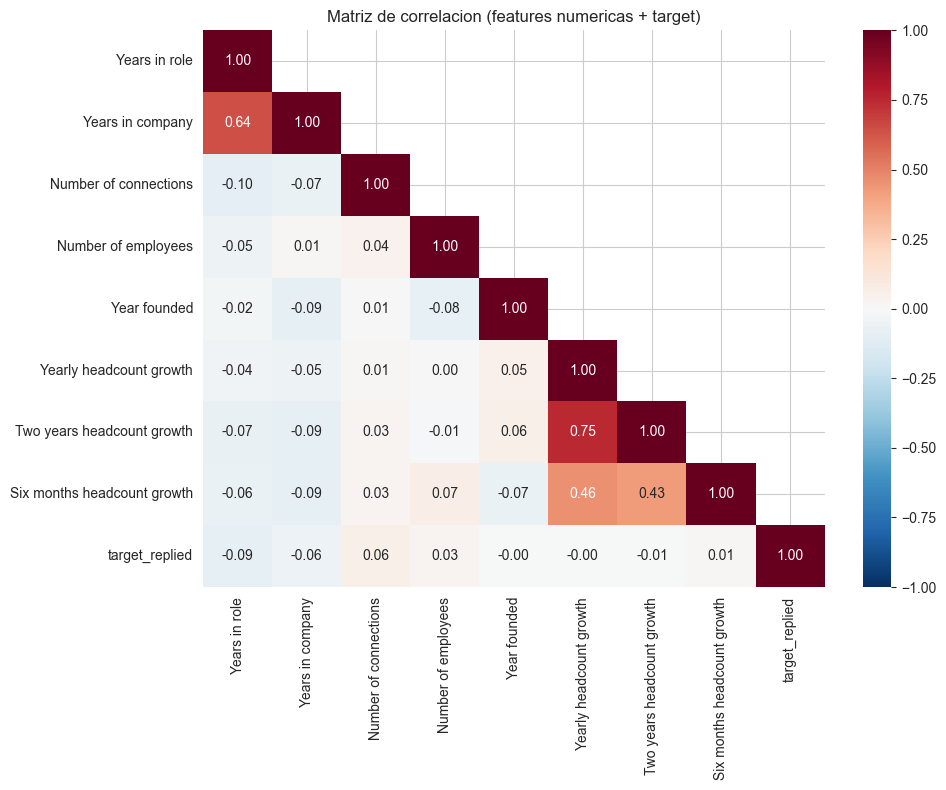


Pares con correlacion > 0.7:
  Yearly headcount growth <-> Two years headcount growth: 0.75


In [41]:
# Correlaciones
corr_cols = ['Years in role', 'Years in company', 'Number of connections',
             'Number of employees', 'Year founded',
             'Yearly headcount growth', 'Two years headcount growth',
             'Six months headcount growth', 'target_replied']
corr_cols = [c for c in corr_cols if c in df.columns and df[c].notna().sum() > 100]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax)
plt.title('Matriz de correlacion (features numericas + target)')
plt.tight_layout()
plt.show()

# Pares con alta correlacion
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], val))

if high_corr:
    print('\nPares con correlacion > 0.7:')
    for c1, c2, v in high_corr:
        print(f'  {c1} <-> {c2}: {v:.2f}')
else:
    print('\nNo hay pares con correlacion > 0.7')

---
## 2.11 Observaciones sobre los FIT scores por producto

Los FIT scores por producto individual (`ai_FIT_IA`, `ai_FIT_COLABORA`, `ai_FIT_INFRA`, 
`ai_FIT_WORKPLACE`, `ai_FIT_MAITE`) estan casí completamente vacios (0-0.5% de datos). 
Solo `ai_FIT_DATA` tiene datos suficientes (93%).

Los valores existentes en FIT_IA y FIT_COLABORA son **textos largos explicativos**, no puntuaciones.
Esto tiene implicaciones para NB03:
- No podemos crear `fe_fit_max` ni `fe_fit_spread` como estaba previsto
- Podemos extraer features de los textos largos de FIT con NLP
- `ai_FIT` general y `ai_FIT_DATA` son las únicas puntuaciones categóricas útilizables

In [42]:
# Resumen de disponibilidad de FIT scores
fit_cols = [c for c in ['ai_FIT', 'ai_FIT_IA', 'ai_FIT_COLABORA', 'ai_FIT_INFRA',
            'ai_FIT_DATA', 'ai_FIT_WORKPLACE', 'ai_FIT_MAITE'] if c in df.columns]

fit_summary = []
for col in fit_cols:
    nn = df[col].notna().sum()
    pct = nn / len(df) * 100
    vals = df[col].dropna().head(3).tolist()
    # Truncar valores largos
    vals_str = [str(v)[:50] + ('...' if len(str(v)) > 50 else '') for v in vals]
    fit_summary.append({
        'Columna': col,
        'No nulos': nn,
        '% datos': f'{pct:.1f}%',
        'Ejemplo': vals_str[0] if vals_str else 'N/A',
    })

print('=== Disponibilidad de FIT scores ===')
print(pd.DataFrame(fit_summary).to_string(index=False))

=== Disponibilidad de FIT scores ===
        Columna  No nulos % datos                                                 Ejemplo
         ai_FIT      5979   99.9%                                                    DUDA
      ai_FIT_IA        39    0.7%                                                      SI
ai_FIT_COLABORA        18    0.3% 🟢 APROBADO + 9\n\nSiemens Gamesa presenta un encaje ...
    ai_FIT_DATA      5979   99.9%                                                      SI


---
## 2.12 Justificación de métricas de evaluación

### Problema: clase desbalanceada

Con 14.0% de positivos, un modelo que siempre prediga "no responde" tendria 86% de accuracy.
Esto hace que accuracy sea una métrica inútil.

### Métricas selecciónadas

| Métrica | Rol | Por qué |
|---------|-----|--------|
| **PR-AUC** | Principal | Mide la capacidad de distinguir positivos sin depender del threshold. Ideal para clases desbalanceadas |
| **ROC-AUC** | Secundaria | Métrica estandar que complementa PR-AUC |
| **Precisión@100** | Negocio | "De los 100 mejores leads, cuantos realmente responderian?" |
| **Precisión@500** | Negocio | Versión más amplia para un mes tipico de outreach |
| **Lift@10%** | Negocio | "Si contactamos solo al top 10%, cuantas veces más respuestas obtenemos vs aleatorio?" |

In [43]:
# Visualizar por que accuracy no sirve
n_total = len(df)
n_pos = df['target_replied'].sum()
n_neg = n_total - n_pos

print('=== Por que no usar accuracy ===')
print(f'Si un modelo siempre predice 0 (no responde):')
print(f'  Accuracy = {n_neg}/{n_total} = {n_neg/n_total:.1%}')
print(f'  Pero detecta {0}/{n_pos} = 0% de los que SI responden')
print(f'  -> Accuracy alta, modelo inutil')
print()
print(f'Nuestro objetivo: identificar el maximo de respondedores en el top del ranking')
print(f'  -> PR-AUC mide exactamente esto')
print(f'  -> Precision@k responde "de mis top k, cuantos son buenos?"')

=== Por que no usar accuracy ===
Si un modelo siempre predice 0 (no responde):
  Accuracy = 5146/5987 = 86.0%
  Pero detecta 0/841 = 0% de los que SI responden
  -> Accuracy alta, modelo inutil

Nuestro objetivo: identificar el maximo de respondedores en el top del ranking
  -> PR-AUC mide exactamente esto
  -> Precision@k responde "de mis top k, cuantos son buenos?"


---
## 2.13 Estrategia de tratamiento de datos (para NB03)

Documentamos aquí las decisiones sobre nulos, outliers y transformaciones que se implementaran en NB03.

### Nulos
| Tipo | Estrategia | Razon |
|------|-----------|-------|
| Numerico (employees, growth) | Mediana + missing indicator | LightGBM maneja nulos nativamente, pero necesitamos compatibilidad con otros modelos |
| Categorico (Seniority, Department) | Categoria "Unknown" | Preserva la información de ausencia |
| Texto (CONTACT REPORT, etc.) | NaN -> texto vacio | Para NLP, se asignara cluster "sin_texto" |
| Columnas 100% nulas (eliminadas en NB01) | Eliminar | Sin información |

### Outliers
| Variable | Estrategia |
|----------|----------|
| Number of employees | Log-transform (distribución muy sesgada) |
| Number of connections | Log-transform |
| Headcount growth | Cap al percentil 1/99 |
| Year founded < 1800 | Reemplazar con NaN |

### Transformaciones
| Feature | Transformación |
|---------|---------------|
| ai_SENIORITY | Ordinal: CLEVEL=4, DIRECTOR=3, MANAGER=2, LEAD=1, JR=0 |
| ai_Contact_score | Ordinal: High=3, Medium=2, Low=1, Disqualified=0 |
| ai_FIT_clean | Ordinal: APROBADO=2, DUDA=1, DESAPROBADO=0 |
| Industry | Target encoding o agrupacion en macro-sectores |

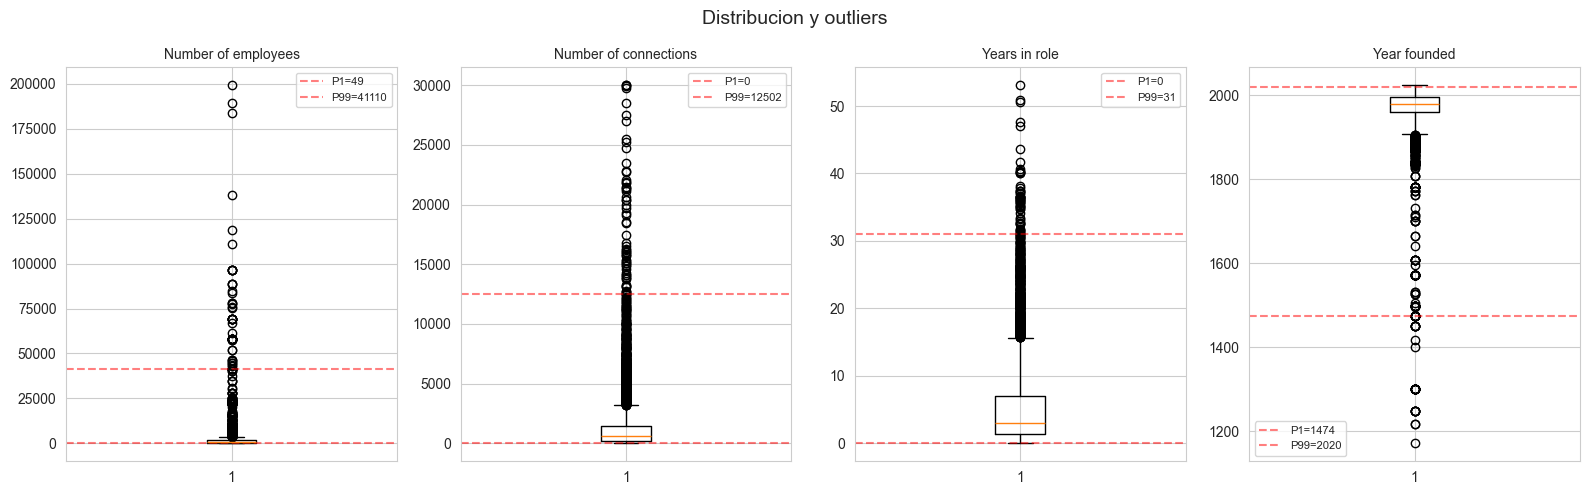

In [44]:
# Visualizar outliers en variables numericas clave
outlier_cols = ['Number of employees', 'Number of connections', 'Years in role', 'Year founded']
existing = [c for c in outlier_cols if c in df.columns and df[c].notna().sum() > 100]

if existing:
    fig, axes = plt.subplots(1, len(existing), figsize=(4*len(existing), 5))
    if len(existing) == 1:
        axes = [axes]
    
    for ax, col in zip(axes, existing):
        data = df[col].dropna()
        ax.boxplot(data, vert=True)
        ax.set_title(col, fontsize=10)
        # Anotar percentiles extremos
        p1, p99 = data.quantile(0.01), data.quantile(0.99)
        ax.axhline(y=p1, color='r', linestyle='--', alpha=0.5, label=f'P1={p1:.0f}')
        ax.axhline(y=p99, color='r', linestyle='--', alpha=0.5, label=f'P99={p99:.0f}')
        ax.legend(fontsize=8)
    
    plt.suptitle('Distribucion y outliers', fontsize=14)
    plt.tight_layout()
    plt.show()

---
## Hallazgos principales

1. **Clase desbalanceada:** 14.0% tasa de respuesta (841 de 5,987 contactos tras filtrar no contactados y no válidos)
2. **LinkedIn domina:** Más respuestas por LinkedIn que por email
3. **TYPE OF CONTACT:** Buyer/Champion (19.8%) y Champion (16.3%) tienen las tasas más altas; los Key Decisión Makers (10.9%) responden por debajo de la media
4. **SENIORITY no es lineal:** Los perfiles intermedios (VP 19.6%, Manager 16.2%) responden más que C-level (11.4%) o Directors (13.0%). La codificación ordinal en NB03 capturara la jerarquia organizativa, pero el modelo aprendera la relacion real con el target
5. **Chi-cuadrado:** SENIORITY, DEPARTMENT y TYPE_OF_CONTACT son estadísticamente significativos (p<0.01). FIT, FIT_DATA y Microsoft NO lo son
6. **FIT scores por producto:** Solo ai_FIT_DATA tiene datos suficientes; los demás son texto o nulos
7. **Columnas vacias:** Eliminadas en NB01 (Gender, Revenue, Jobs posted from LinkedIn,
   ai_FIT_INFRA, ai_FIT_WORKPLACE, ai_FIT_MAITE, TYPE OF CONTACT - Para Ajustar)
8. **Timing:** Los días laborables con alto volumen muestran tasas más fiables; fines de semana tienen volumen insuficiente
9. **Conversation tags:** No todas las respuestas son positivas; un target basado solo en respuestas positivas es trabajo futuro

### Próximo paso: NB03 - Feature Engineering + NLP